# 04 — From "discover the classes" to "learn the physics": where this project stands

**A plain-language tour of the current approach — amortized dynamical invariants — and its first results (2026-07-02).**

You need no background in this project to read this notebook. If you know roughly
what a neural network is and don't mind pictures made of black-and-white pixels,
you are fully equipped. Everything below runs in seconds-to-minutes on a laptop:
no training happens here — the heavy runs are already done, and this notebook
loads their results from `runs/lever_a*/`.

The story in four sentences:

1. We study **cellular automata** — tiny artificial universes — and want a machine
   that can sort their *behaviours* the way a naturalist sorts animals.
2. Our first approach (self-supervised learning on the raw images; notebook 01)
   **failed its own pre-registered test**, and a commissioned literature review
   showed that the goal, as originally stated, was ill-posed.
3. The reframed approach: *measure* behaviour directly with a small perturbation
   experiment, then train a network to **estimate those measurements from a
   single image** — a trick called *amortization*.
4. That approach just **passed its pre-registered test, twice** — with one
   scientifically interesting caveat that points to the next step.

Full technical record: `RESULTS.md` (measurements), `FOUNDATIONS.md` (why the
reframe), `EVALUATION_CRITERIA.md` (the pre-registered pass/fail bars).

> **Where this sits in the project arc (added 2026-07-05).** This is the v2
> ('learn the physics') arc: invariant amortization (criterion 6), spatial
> maps for non-uniform CA (criterion 7), the resolution/alloy stress test
> (criterion 8), and the radius-two space M4 (criterion 9). It ends where the
> manuscript begins. **The final act — two referee rounds, the mechanistic
> read-the-rule estimator, the corrected reliability benchmarks, and the
> identifiability phase diagram — is narrated in `05_reading_the_rule.ipynb`**;
> the executive-decision log is `../DECISIONS.md`.

## 1. The simplest possible universes

An **elementary cellular automaton (ECA)** is a one-dimensional row of cells,
each either black or white. Time ticks forward in steps; at every tick, each
cell looks at itself and its two neighbours and consults a fixed rule table
("if my left neighbour is black, I am white, and my right neighbour is black →
next tick I become white"). There are exactly 256 possible rule tables, numbered
0–255. That's it — the entire "physics" of one of these universes fits in eight
bits.

To *see* a universe, we start it from a random row and stack the successive rows
into an image: **space runs left–right, time runs top–down**. The remarkable
thing — the reason people have studied these toys for forty years — is how
different the resulting histories look, given that all 256 universes have the
same kind of physics:

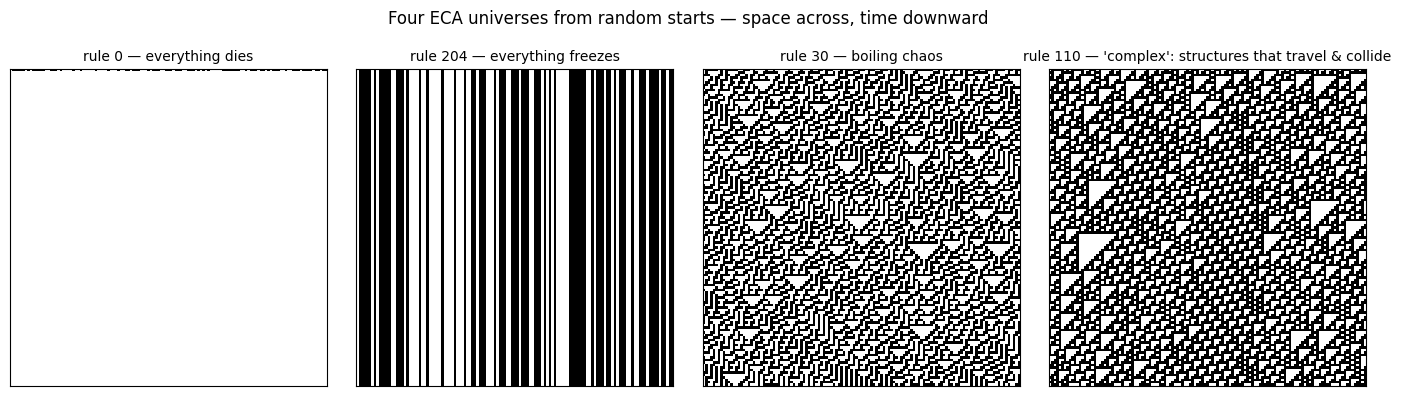

In [1]:
# Environment & imports (MPS fallback on, per CLAUDE.md; everything here is CPU-light).
import os
os.environ.setdefault("PYTORCH_ENABLE_MPS_FALLBACK", "1")

import warnings
warnings.filterwarnings("ignore")

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

from caspectra.ca.eca import ECASimulator

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
np.random.seed(0); torch.manual_seed(0)


def diagram(rule, size=127, seed=0):
    # One spacetime diagram from a seeded random initial row. Size is odd on
    # purpose: on a power-of-two ring some rules artificially collapse to blank
    # (see notebook 01's "power-of-two trap").
    rng = np.random.default_rng(seed)
    return ECASimulator(rule).random_diagram(width=size, n_steps=size, rng=rng)


SHOWCASE = {
    0:   "rule 0 — everything dies",
    204: "rule 204 — everything freezes",
    30:  "rule 30 — boiling chaos",
    110: "rule 110 — 'complex': structures that travel & collide",
}

fig, axes = plt.subplots(1, 4, figsize=(14, 3.8))
for ax, (rule, title) in zip(axes, SHOWCASE.items()):
    ax.imshow(diagram(rule), cmap="binary", interpolation="nearest")
    ax.set_title(title, fontsize=10); ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("Four ECA universes from random starts — space across, time downward", y=1.03)
fig.tight_layout(); plt.show()

A naturalist would immediately sort these: *dead*, *frozen*, *turbulent*, and —
the interesting one — *complex*, where localized structures ("gliders") travel
across an organized background and collide. Rule 110 is famous because those
collisions can be wired up to perform any computation: a Turing-complete
universe in eight bits.

The project's founding question: **can a machine discover this kind of
behavioural sorting on its own, from the images alone, without being told the
rules or the categories?**

## 2. Why the first approach failed: the fingerprint problem

Our first attempt used **self-supervised learning (SSL)** — the family of
methods behind modern image models. The recipe: show a network two slightly
altered copies of the same image and train it to recognize them as "the same
thing". With no labels at all, the network invents its own notion of
similarity, which you then hope aligns with the similarity you care about.

For photographs this works wonderfully. For cellular automata it fails in a
subtle, instructive way. Every rule leaves the same microscopic **texture
fingerprint** in every image it produces — the same little arrangements of
pixels, over and over, because the same eight-bit table generated all of them.
The easiest way for the network to say "these two images are the same thing" is
to read that fingerprint. It's as if we asked someone to sort letters by the
*language* they're written in, and they aced the test by recognizing each
individual *author's handwriting* — every Spanish letter in the pile happened
to be written by one of three people. Right answers, wrong concept, and it
falls apart the moment a new author shows up.

Look how plausible the shortcut is — two images from the *same* rule share fine
texture in a way two behaviourally similar rules do not:

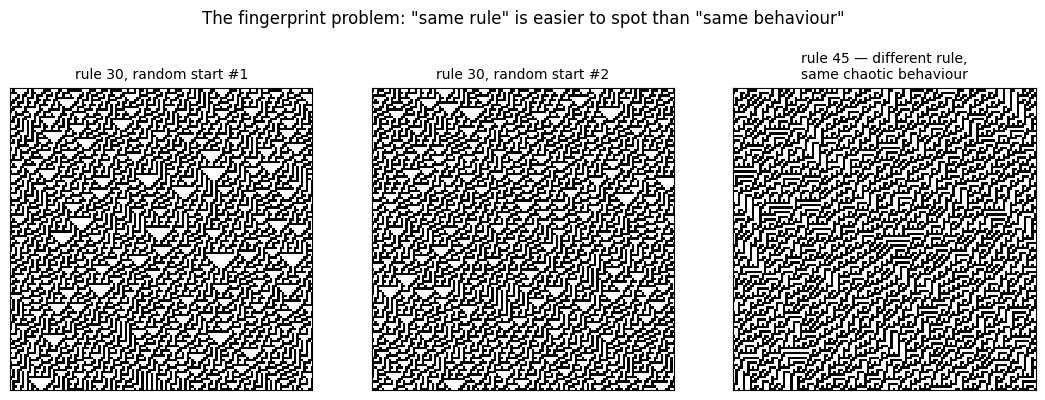

In [2]:
panels = [
    (diagram(30, seed=0), "rule 30, random start #1"),
    (diagram(30, seed=1), "rule 30, random start #2"),
    (diagram(45, seed=0), "rule 45 — different rule,\nsame chaotic behaviour"),
]
fig, axes = plt.subplots(1, 3, figsize=(11, 3.8))
for ax, (img, title) in zip(axes, panels):
    ax.imshow(img, cmap="binary", interpolation="nearest")
    ax.set_title(title, fontsize=10); ax.set_xticks([]); ax.set_yticks([])
fig.suptitle('The fingerprint problem: "same rule" is easier to spot than "same behaviour"', y=1.04)
fig.tight_layout(); plt.show()

We built defences against this (special network architectures, blurring
augmentations — notebook 01 tells that story) and pre-registered a test. The
measured verdict (`RESULTS.md`, 2026-07-01) was unambiguous:

- The trained SSL model could name **the exact rule as well as it could name
  the behaviour class** — the fingerprint won despite every defence.
- Worse: on the metric that matters most — *finding the complex, computing
  rules* — the deep model scored **0.00**, while **four cheap physics
  measurements scored a perfect 1.00** (§3 shows you those four numbers).

Around the same time, a literature review (`FOUNDATIONS.md`) established that
the dream in its strong form — "*the* true behavioural classification,
discovered from images with no assumptions" — is not just hard but **ill-posed**:
provably no algorithm can decide the classic behaviour classes in general, the
observed behaviour genuinely depends on how you set up the experiment (world
size, random-start recipe, observation time), and label-free clustering always
smuggles in *some* notion of similarity. There is no view from nowhere.

So the project pivoted. Not "let the machine discover what behaviour means",
but: **define behaviour operationally, with an experiment — then let the
machine learn to estimate that experiment's outcome cheaply.**

## 3. The butterfly test: measuring behaviour directly

Here is the operational definition, and it is pleasingly physical. Take a
universe, run it. Now rerun it from the *same* random start **with a single
cell flipped** — one pixel of difference, the proverbial butterfly. Evolve both
copies and watch where they disagree (the "**damage**"):

- In a *dead or frozen* universe, the flip heals or stays put.
- In a *chaotic* universe, it explodes outward into a dense, widening cone.
- In a *complex* universe, it does something in between — it survives and
  spreads, but more slowly, carried along by travelling structures rather than
  a wall of noise.

This "damage spreading" experiment is a classic tool from statistical physics,
and it measures exactly the thing the naturalist's eye responds to. Watch it
run on our four showcase universes (right column = where the twins disagree):

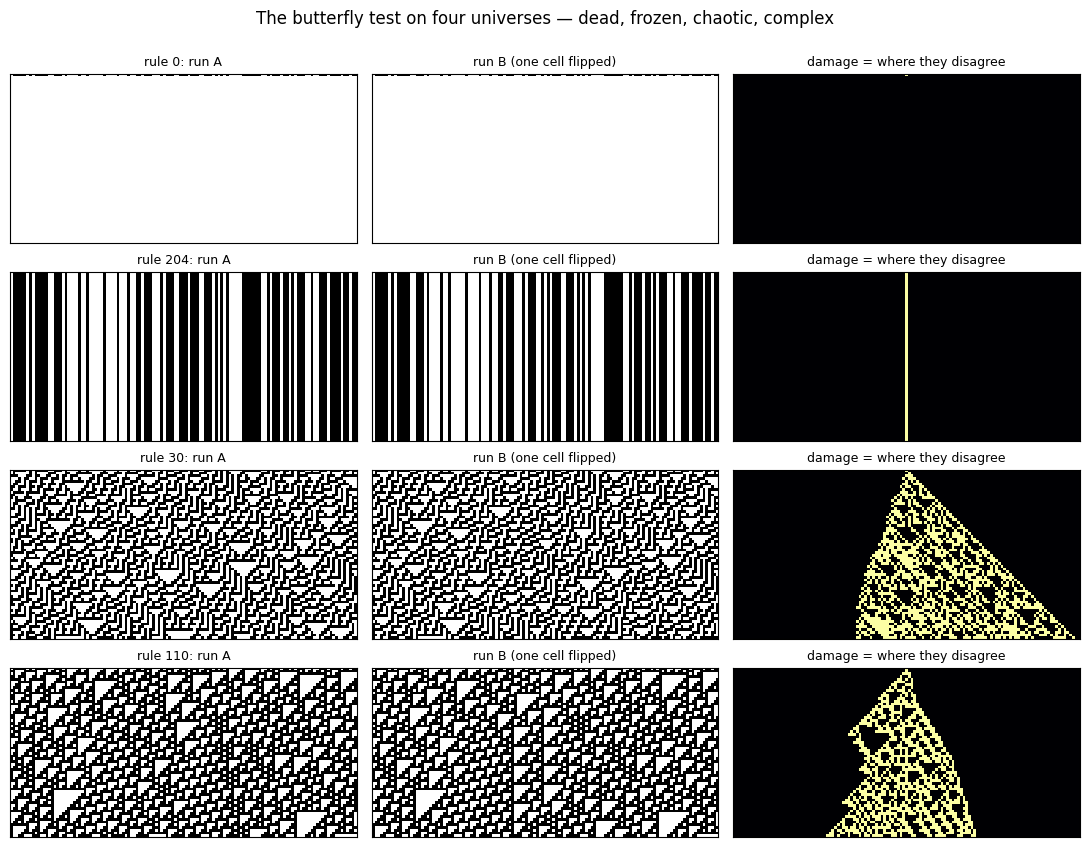

In [3]:
def twin_run(rule, width=127, seed=0):
    # Twin experiment, same conventions as caspectra/eval/dynamics.py:
    # horizon width//2 - 1 keeps the damage cone from wrapping around the ring.
    rng = np.random.default_rng(seed)
    sim = ECASimulator(rule)
    n_steps = width // 2 - 1
    ic = rng.integers(0, 2, size=width, dtype=np.uint8)
    ic_flipped = ic.copy()
    ic_flipped[width // 2] ^= 1  # flip the middle cell
    a = sim.evolve(ic, n_steps)
    b = sim.evolve(ic_flipped, n_steps)
    return a, b, (a != b)


rules = [0, 204, 30, 110]
fig, axes = plt.subplots(4, 3, figsize=(11, 8.5))
for row, rule in enumerate(rules):
    a, b, damage = twin_run(rule)
    for col, (img, cmap, title) in enumerate([
        (a, "binary", f"rule {rule}: run A"),
        (b, "binary", "run B (one cell flipped)"),
        (damage, "inferno", "damage = where they disagree"),
    ]):
        ax = axes[row, col]
        ax.imshow(img, cmap=cmap, interpolation="nearest")
        ax.set_title(title, fontsize=9); ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("The butterfly test on four universes — dead, frozen, chaotic, complex", y=1.0)
fig.tight_layout(); plt.show()

The damage pictures separate the behaviours at a glance: nothing, a single
hairline, a wide fiery cone — and, for rule 110, a **narrower, more ragged
cone** that advances in fits and starts, with voids where the disturbance is
carried by discrete travelling structures instead of raw noise. That
difference in how damage propagates *is* the thing the naturalist's eye was
responding to in §1.

We distil each damage picture into **four numbers** (the "invariants"), asking:

1. **Survival** — did the disturbance survive to the end at all?
2. **Damage fraction** — how much of the world does it touch?
3. **Spreading rate** — how fast does the cone widen? (1.0 = the maximum speed
   information can travel in this universe)
4. **Cone fill** — inside the cone, is the damage *solid* (chaos) or *lacy*
   (travelling structures)?

Because these numbers come from an experiment rather than from labels or
opinion, they are **measurements, not judgements**. Computing them for our
showcase (plus a few more rules):

In [4]:
from caspectra.eval.dynamics import DYNAMICS_FEATURE_NAMES, damage_spreading_features

DEMO = [0, 204, 184, 90, 30, 18, 110, 54]  # 54 is the other famous 'complex' rule
print(f"{'rule':>5} | " + " | ".join(f"{n:>15}" for n in DYNAMICS_FEATURE_NAMES))
print("-" * 79)
rng = np.random.default_rng(0)
for rule in DEMO:
    f = damage_spreading_features(rule, width=127, n_pairs=32, rng=rng)
    print(f"{rule:>5} | " + " | ".join(f"{v:>15.3f}" for v in f))

 rule | damage_survival | damage_fraction |  spreading_rate |       cone_fill
-------------------------------------------------------------------------------
    0 |           0.000 |           0.000 |           0.000 |           0.000
  204 |           1.000 |           0.008 |           0.008 |           1.000
  184 |           1.000 |           0.029 |           0.029 |           1.000
   90 |           1.000 |           0.252 |           0.992 |           0.260
   30 |           1.000 |           0.315 |           0.628 |           0.514
   18 |           0.656 |           0.268 |           0.912 |           0.304
  110 |           0.969 |           0.184 |           0.378 |           0.499
   54 |           1.000 |           0.155 |           0.421 |           0.407


Read the last two rows: rules 110 and 54 — the two celebrated "complex"
universes — sit in a regime of their own. Their damage (nearly) always
survives, like chaos and unlike order; but their cones widen at **less than
half the chaotic pace** (spreading rate ≈ 0.38–0.42, against 0.63–0.99 for
the chaotic rules 30, 18 and 90). No single number does the job — it is the
*combination* that carves out a small in-between region, and that region
contains exactly the famous complex rules. Clustering the 88
essentially-distinct rules on these four numbers groups {54, 110} together
with perfect complex-class recall — the thing the SSL model never managed
(`RESULTS.md`, 2026-07-01).

> **One honest footnote.** These numbers depend on the *experimental protocol* —
> the world size, and especially the density of black cells in the random start.
> We measured this (`RESULTS.md`, criterion 5): the fine-grained sorting of rules
> genuinely shifts if you change the starting-density recipe, exactly as the
> theory literature predicts. So every claim in this project is about behaviour
> *under a stated protocol* (random 50/50 starts, ring of 127 cells, 127 steps) —
> not about "the" behaviour of a rule in the abstract. There is no
> protocol-free classification; the fix is to say your protocol out loud.

## 4. The catch — and the new job for the neural network

If four numbers from a cheap experiment sort the universes so well, why involve
machine learning at all?

Because the butterfly test **needs things you usually don't have**. To run it
you must (a) know the rule, so you can re-run the universe, and (b) be able to
restart the world twice from identical conditions. For ECAs that's trivial. For
the systems this project ultimately cares about — universes whose physics
*varies from place to place* (non-uniform CAs), or a single observed history of
an unknown system — it's impossible. You get **one picture**, no rewind button.

So the network's new job is *estimation*, not discovery: **look at a single
spacetime image and predict what the butterfly test *would* say** — the way a
forester estimates a hillside's flammability from one photograph, without
burning it down twice to compare. In machine-learning jargon this is
**amortization**: pay once, at training time, for many expensive twin-run
experiments; afterwards, get their answer from any single image at a glance.

Two things make this a much better-posed job than the original one:

- The targets are **experimental outcomes**, not human categories — nothing
  subjective is baked in.
- The targets are **honest work**: the four numbers depend on the twin run,
  which the network never sees. It cannot "cheat" by computing them directly
  from its input; it must internalize how each texture *responds* to
  perturbation. (Even the fingerprint shortcut is defanged: reading *which rule
  made this* is now, at worst, a stepping stone to the physics, not a way
  around it.)

## 5. The honest exam: grading only on universes it has never seen

How do you test such a network fairly? Not by asking it about rules it was
trained on — it could just memorize each rule's four numbers. The
pre-registered test (**criterion 6** in `EVALUATION_CRITERIA.md`) is
**leave-rules-out**: hide 18 of the 88 essentially-distinct rules during
training, then ask the network for the invariants of those never-seen
universes and compare against the true twin-run measurements. The agreement
score is R² (1.0 = perfect, 0 = no better than guessing the average);
the bar for success was set at **median R² ≥ 0.5, decided before training**.

Because the complex rules are the scientifically precious ones, we ran the
exam **twice**: once holding out rule 110 (training on 54), and once the other
way around. Below we load the results of both finished runs:

In [5]:
def load_summary(run):
    with open(ROOT / run / "eval" / "summary.json") as fh:
        return json.load(fh)

main, swap = load_summary("runs/lever_a"), load_summary("runs/lever_a_swap")

print("Criterion 6 — rule-level R² on the 18 held-out (never-seen) rules")
print(f"{'invariant':>16} | {'main (110 out)':>15} | {'swap (54 out)':>15}")
print("-" * 54)
for name in DYNAMICS_FEATURE_NAMES:
    print(f"{name:>16} | {main['criterion6_rule_level_r2'][name]:>15.3f} "
          f"| {swap['criterion6_rule_level_r2'][name]:>15.3f}")
print("-" * 54)
print(f"{'median':>16} | {main['criterion6_median_r2']:>15.3f} | {swap['criterion6_median_r2']:>15.3f}")
print(f"{'verdict':>16} | {main['criterion6_verdict']:>15} | {swap['criterion6_verdict']:>15}"
      f"   (pre-registered bar: median ≥ 0.5)")

Criterion 6 — rule-level R² on the 18 held-out (never-seen) rules
       invariant |  main (110 out) |   swap (54 out)
------------------------------------------------------
 damage_survival |           0.694 |           0.700
 damage_fraction |           0.797 |           0.808
  spreading_rate |           0.970 |           0.956
       cone_fill |           0.929 |           0.863
------------------------------------------------------
          median |           0.863 |           0.836
         verdict |            PASS |            PASS   (pre-registered bar: median ≥ 0.5)


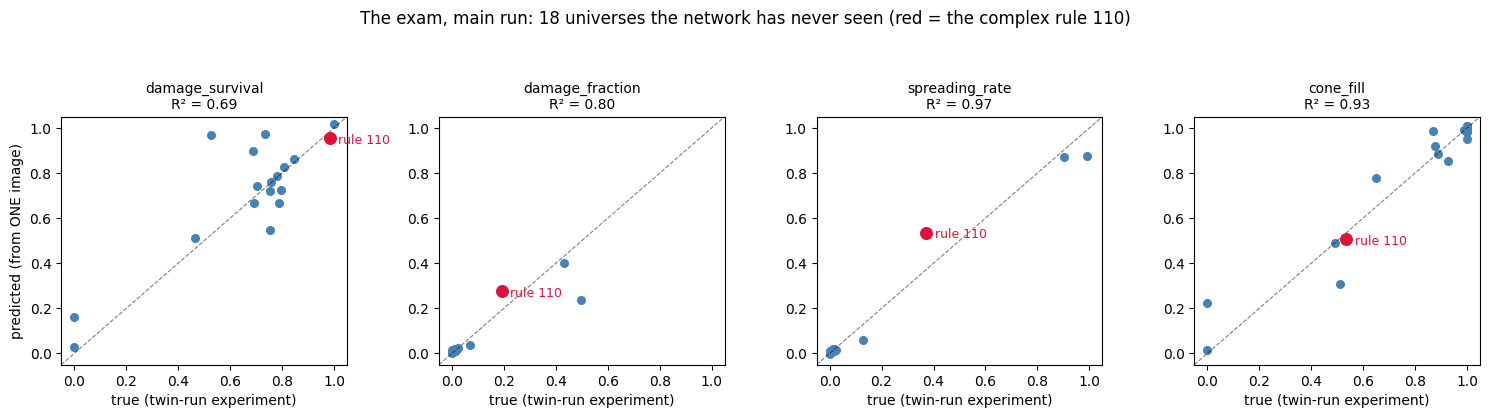

In [6]:
# Predicted vs true, one panel per invariant, over the 18 held-out rules (main run).
per_rule = main["per_held_out_rule"]
fig, axes = plt.subplots(1, 4, figsize=(15, 3.9))
for i, (ax, name) in enumerate(zip(axes, DYNAMICS_FEATURE_NAMES)):
    for rule_str, rec in per_rule.items():
        is_110 = rule_str == "110"
        ax.scatter(rec["true"][i], rec["predicted"][i],
                   c="crimson" if is_110 else "steelblue",
                   s=70 if is_110 else 30, zorder=3 if is_110 else 2)
        if is_110:
            ax.annotate("rule 110", (rec["true"][i], rec["predicted"][i]),
                        textcoords="offset points", xytext=(6, -4), fontsize=9, color="crimson")
    lim = [-0.05, 1.05]
    ax.plot(lim, lim, "k--", lw=0.8, alpha=0.5)
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel("true (twin-run experiment)")
    if i == 0:
        ax.set_ylabel("predicted (from ONE image)")
    ax.set_title(f"{name}\nR² = {main['criterion6_rule_level_r2'][name]:.2f}", fontsize=10)
fig.suptitle("The exam, main run: 18 universes the network has never seen (red = the complex rule 110)", y=1.06)
fig.tight_layout(); plt.show()

**Both runs pass, comfortably** (medians 0.863 and 0.836 against a bar of 0.5).
Read the panels: the points hug the diagonal — from a *single* picture of a
universe it has never encountered, the network recovers, with useful accuracy,
what a twin-run perturbation experiment would have measured. Spreading rate is
the star (R² ≈ 0.96–0.97); survival is the weakest (≈ 0.70), largely because it
is nearly all-or-nothing across rules, so small misses are punished harshly.

One more reassurance worth stating: the network reached this accuracy almost
immediately during training, and its internal representation organizes along
≈ 4 directions — essentially the four invariants themselves. It learned the
physics summary, not an 88-entry lookup table.

## 6. The caveat that matters: one complex example is not enough

Now look at the red point above, and at its mirror image in the swapped run:

In [7]:
print("The unseen complex rule, in both runs  (order: "
      + ", ".join(DYNAMICS_FEATURE_NAMES) + ")\n")
for run, summ, held in [("main", main, "110"), ("swap", swap, "54")]:
    rec = summ["per_held_out_rule"][held]
    print(f"{run} run — rule {held} was held out:")
    print(f"   true      {[round(v, 3) for v in rec['true']]}")
    print(f"   predicted {[round(v, 3) for v in rec['predicted']]}\n")

The unseen complex rule, in both runs  (order: damage_survival, damage_fraction, spreading_rate, cone_fill)

main run — rule 110 was held out:
   true      [0.984, 0.192, 0.372, 0.536]
   predicted [0.957, 0.277, 0.536, 0.507]

swap run — rule 54 was held out:
   true      [0.977, 0.178, 0.436, 0.431]
   predicted [0.844, 0.09, 0.185, 0.733]



Both runs misjudge the never-seen complex rule — **in opposite directions**:

- With 110 hidden, its spreading rate is predicted at **0.54 vs a true 0.37** —
  nudged *up*, toward the chaotic rules the network knows well.
- With 54 hidden, its rate is predicted at **0.18 vs a true 0.44** — nudged
  *down*, toward the tamer "locally chaotic" rules.

The pattern is easy to interpret and important: the complex regime sits
*between* order and chaos, and each training set contained exactly **one**
example of it. Asked about an unseen in-between universe, the network does the
sensible statistical thing — it rounds toward the nearest regime it has seen
many examples of. The amortizer passes its exam (the four numbers are recovered
well overall), but a reliable *detector of never-seen complex universes* will
need training data where complexity is not a two-member club. Elementary CAs
simply cannot provide that — there are only ~2 such rules among 88.

This is the strongest quantitative argument yet for the project's next
milestone: **a larger rule space** (bigger neighbourhoods / more states), where
glider-supporting rules are plentiful and the in-between regime can be properly
populated.

## 7. The payoff: behaviour as a *map*, not a single number

Why insist on estimating from a single image? Because a network that does so
convolutionally gives us something the twin-run experiment structurally cannot:
**a spatial map of behaviour**. The trained network summarizes each local patch
of the image before averaging into its final answer — so instead of averaging,
we can read the prediction *at every patch*: a weather map of "how chaotic is
it *here*". (A tidy technical fact: the average of this map is exactly the
network's global prediction — the map is the prediction, unbundled.)

For ordinary ECAs the map is mostly a curiosity — the physics is the same
everywhere. But for **non-uniform CAs**, where different regions follow
different rules, it is the entire point: no twin-run experiment can hand you a
per-region behaviour estimate from one observed history. Let's render the maps
from the trained network:

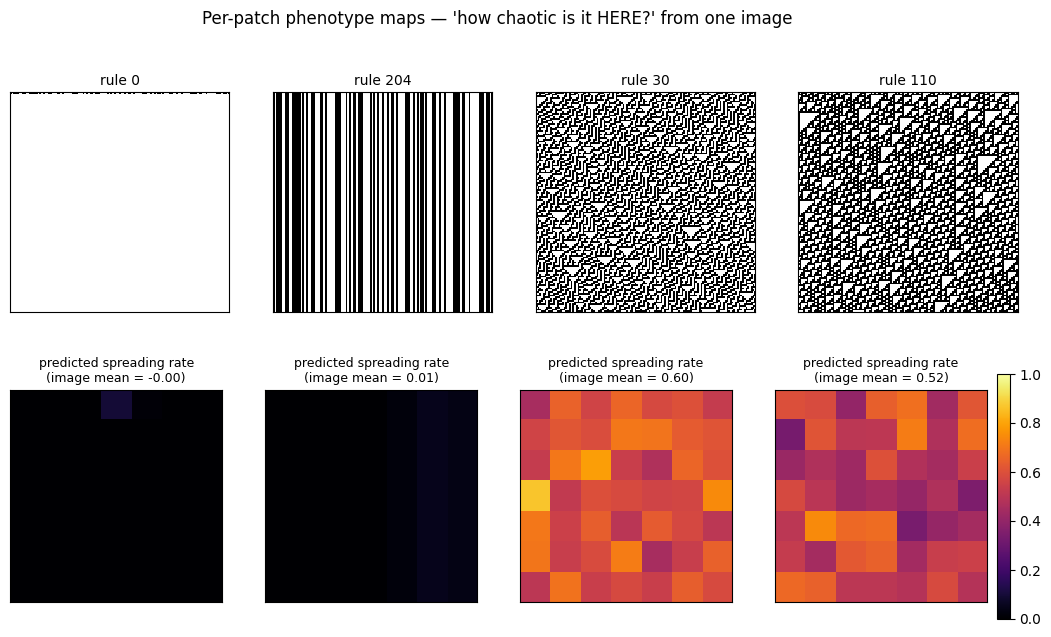

In [8]:
from caspectra.config import ExperimentConfig
from caspectra.factory import build_model

cfg = ExperimentConfig.from_yaml(str(ROOT / "configs/lever_a.yaml"))
ck = torch.load(ROOT / "runs/lever_a/checkpoint_final.pt",
                map_location="cpu", weights_only=False)
model = build_model(cfg.model)
model.load_state_dict(ck["model_state"])
model.eval()

# Predictions are made in standardized-target space; undo with the stored scaler.
mean = torch.tensor(ck["scaler_mean"], dtype=torch.float32)
std = torch.tensor(ck["scaler_std"], dtype=torch.float32)
RATE = DYNAMICS_FEATURE_NAMES.index("spreading_rate")

rules = [0, 204, 30, 110]
fig, axes = plt.subplots(2, 4, figsize=(13, 7))
with torch.no_grad():
    for col, rule in enumerate(rules):
        img = diagram(rule, seed=7)
        x = torch.from_numpy(img).float().unsqueeze(0).unsqueeze(0)
        pmap = model.predict_map(x) * std.view(1, -1, 1, 1) + mean.view(1, -1, 1, 1)
        glob = model(x) * std + mean
        # Consistency identity: the map's mean IS the global prediction.
        assert torch.allclose(pmap.mean(dim=(-2, -1)), model(x) * std + mean, atol=1e-4)
        axes[0, col].imshow(img, cmap="binary", interpolation="nearest")
        axes[0, col].set_title(f"rule {rule}", fontsize=10)
        im = axes[1, col].imshow(pmap[0, RATE].numpy(), cmap="inferno",
                                 vmin=0, vmax=1, interpolation="nearest")
        axes[1, col].set_title(
            f"predicted spreading rate\n(image mean = {glob[0, RATE]:.2f})", fontsize=9)
        for ax in (axes[0, col], axes[1, col]):
            ax.set_xticks([]); ax.set_yticks([])
fig.colorbar(im, ax=axes[1, :].tolist(), fraction=0.02, pad=0.01)
fig.suptitle("Per-patch phenotype maps — 'how chaotic is it HERE?' from one image", y=0.98)
plt.show()

The maps behave as physics says they should: rule 0's map is near zero
everywhere, with only a faint trace along the top rows where the initial
flurry dies out; rule 204 reads cold; rule 30 reads hot. And the last panel
quietly replays §6 in spatial form: this checkpoint is the *main* run, which
never saw rule 110 — its map reads too hot (image mean ≈ 0.52 against a true
rate of 0.37), the one-complex-example bias made visible.

The current resolution is coarse (the encoder pools the 127×127 image down to
7×7 patches — each pixel of the map summarizes a ~16-cell neighbourhood), so
treat these as a proof of principle. A quantitative exam on genuinely
non-uniform universes is exactly what the next section delivers — and it
caught a real flaw in this very network before certifying a fixed one.

## 8. The stress test: patchwork universes

Everything so far graded the network on *uniform* universes — one rule
everywhere. But the whole reason to want a behaviour **map** is the case where
the physics varies in space: a **non-uniform CA**, say rule 0 (a dead universe)
on the left half of the ring and rule 30 (boiling chaos) on the right. For such
a system a single observed history is all you ever get — no twin-run experiment
can grade the two halves separately. If the phenotype maps are real
measurements, they should read each half correctly. If they are a mirage, this
is where it shows.

As before, the exam was **pre-registered before any measurement was taken**
(criterion 7 in `EVALUATION_CRITERIA.md`, revision 3): 16 training rules
spanning all behaviour regimes, glued together in all 120 pairs with 8 random
starts each; readings taken only from patches far enough from the rule
interfaces (> 16 cells, the network's field of view) to see a single rule; the
same bars as criterion 6 (median R² ≥ 0.5 passes, < 0.2 fails). A control where
"both" rules are the same rule must reproduce the uniform-universe prediction
*exactly* — it does, to the last bit.

First, what these patchwork universes and their maps look like (using the
current best network — the section explains how it earned that title):

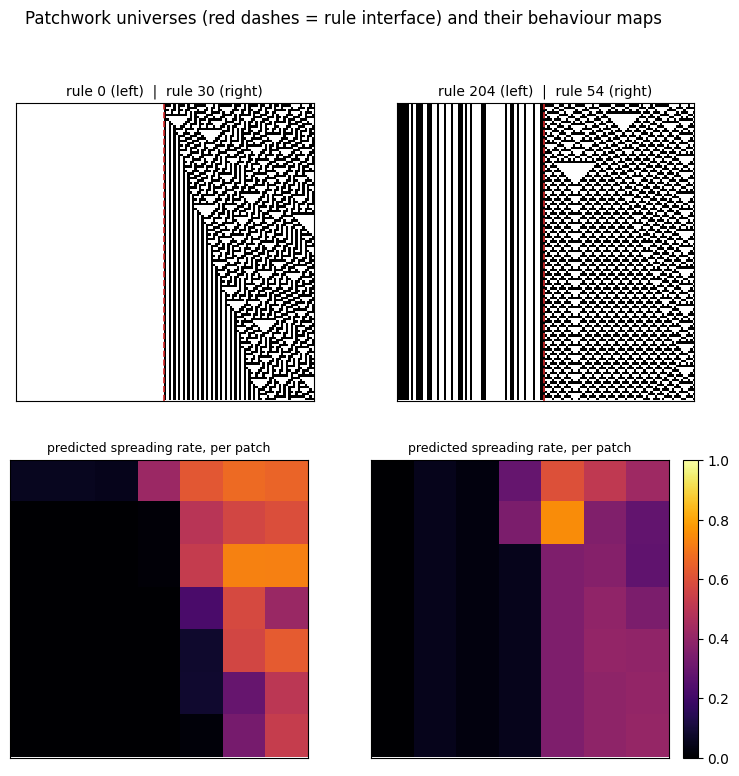

    universe |     half | map reads (rate) | direct twin-run
--------------------------------------------------------------
      0 | 30 |   rule 0 |           -0.009 |           0.000
      0 | 30 |  rule 30 |            0.411 |           0.626
    204 | 54 | rule 204 |            0.038 |           0.008
    204 | 54 |  rule 54 |            0.422 |           0.429


In [9]:
from caspectra.ca.nuca import NonUniformCA, half_mask
from caspectra.eval.nuca_metrics import region_columns, region_means

# The revised "local-norm" network (runs/lever_a_local) and its scaler.
cfg_local = ExperimentConfig.from_yaml(str(ROOT / "configs/lever_a_local.yaml"))
ck_local = torch.load(ROOT / "runs/lever_a_local/checkpoint_final.pt",
                      map_location="cpu", weights_only=False)
model_local = build_model(cfg_local.model)
model_local.load_state_dict(ck_local["model_state"])
model_local.eval()
mean_l = torch.tensor(ck_local["scaler_mean"], dtype=torch.float32)
std_l = torch.tensor(ck_local["scaler_std"], dtype=torch.float32)

MASK = half_mask(127)  # rule_a on cells [0, 63), rule_b on the rest of the ring


def composed(rule_left, rule_right, seed=3):
    rng = np.random.default_rng(seed)
    return NonUniformCA(rule_left, rule_right, MASK).random_diagram(127, 127, rng)


def phenotype_map(model_, mean_, std_, img):
    x = torch.from_numpy(img).float().unsqueeze(0).unsqueeze(0)
    with torch.no_grad():
        pmap = model_.predict_map(x) * std_.view(1, -1, 1, 1) + mean_.view(1, -1, 1, 1)
    return pmap[0].numpy()


pairs = [(0, 30), (204, 54)]
fig, axes = plt.subplots(2, 2, figsize=(9, 8.5))
for col, (ra, rb) in enumerate(pairs):
    img = composed(ra, rb)
    pmap = phenotype_map(model_local, mean_l, std_l, img)
    axes[0, col].imshow(img, cmap="binary", interpolation="nearest")
    axes[0, col].axvline(62.5, color="tab:red", lw=1.2, ls="--")
    axes[0, col].set_title(f"rule {ra} (left)  |  rule {rb} (right)", fontsize=10)
    im = axes[1, col].imshow(pmap[RATE], cmap="inferno", vmin=0, vmax=1,
                             interpolation="nearest")
    axes[1, col].set_title("predicted spreading rate, per patch", fontsize=9)
    for ax in axes[:, col]:
        ax.set_xticks([]); ax.set_yticks([])
fig.colorbar(im, ax=axes[1, :].tolist(), fraction=0.03, pad=0.02)
fig.suptitle("Patchwork universes (red dashes = rule interface) and their behaviour maps", y=0.99)
plt.show()

# Read the map per half (interface band excluded) vs the direct experiment.
cols_by_region, _ = region_columns(MASK, map_width=7, exclusion_px=16.0)
rng = np.random.default_rng(1)
print(f"{'universe':>12} | {'half':>8} | {'map reads (rate)':>16} | {'direct twin-run':>15}")
print("-" * 62)
for ra, rb in pairs:
    img = composed(ra, rb)
    means = region_means(phenotype_map(model_local, mean_l, std_l, img), cols_by_region)
    for region, rule in [(0, ra), (1, rb)]:
        true = damage_spreading_features(rule, width=127, n_pairs=32, rng=rng)[RATE]
        print(f"{f'{ra} | {rb}':>12} | {f'rule {rule}':>8} "
              f"| {means[region][RATE]:>16.3f} | {true:>15.3f}")

The maps read the right physics on the right side of the seam: the dead and
frozen halves stay cold, the chaotic and complex halves run hot. Three of the
four readings above land close to the direct twin-run value; the chaotic half
is read as clearly hot but under-called on this particular random start — the
graded exam below averages over 120 pairs × 8 starts before judging.

But this happy picture is the *ending* of the story. The first time we ran the
full graded exam — on the original network of §5–§7, frozen, no retraining — it
scored a median R² of **0.433**: above the pre-registered failure bar, well
below the pass bar. The *rankings* were fine (the hotter half read hotter more
than 8 times in 10), but the calibration was off, and it was worst for dead and
frozen regions, which read far too alive whenever something interesting was
happening in the **other half of the universe**.

That last clause is the clue. A dead region's reading should not depend on its
neighbour at all. So: same dead half (rule 0) every time, five different
partners, and we ask each network what it sees in the *dead half only*:

In [10]:
SURV = DYNAMICS_FEATURE_NAMES.index("damage_survival")


def dead_half_reading(model_, mean_, std_, partner):
    # Mean survival read off the rule-0 half (interface band excluded), 4 starts.
    vals = []
    for seed in range(4):
        img = composed(0, partner, seed=seed)
        pmap = phenotype_map(model_, mean_, std_, img)
        vals.append(region_means(pmap, cols_by_region)[0][SURV])
    return float(np.mean(vals))


print("Survival reading of the DEAD half (true value: 0.0, whatever the partner)")
print(f"{'other half':>16} | {'original network':>17} | {'local-norm network':>19}")
print("-" * 60)
for partner in [0, 204, 184, 54, 30]:
    label = "rule 0 (uniform)" if partner == 0 else f"rule {partner}"
    print(f"{label:>16} | {dead_half_reading(model, mean, std, partner):>17.3f} "
          f"| {dead_half_reading(model_local, mean_l, std_l, partner):>19.3f}")

Survival reading of the DEAD half (true value: 0.0, whatever the partner)
      other half |  original network |  local-norm network
------------------------------------------------------------
rule 0 (uniform) |             0.036 |              -0.035
        rule 204 |             0.697 |              -0.035
        rule 184 |             0.492 |              -0.035
         rule 54 |             0.690 |              -0.035
         rule 30 |             0.781 |              -0.035


The original network flunks the probe spectacularly: its reading of a dead,
featureless region swings across half the scale purely with the identity of a
neighbour it should be ignoring. The revised network's reading does not move at
all — same value, to the third decimal, for every partner.

The mechanism, once found, is mundane and instructive. The original encoder
normalized its internal signals using **whole-image statistics** (GroupNorm — a
sensible default inherited from the SSL baseline). That means every patch was
graded *on a curve set by the entire class*: put a wild rule in the other half
and the curve shifts, dragging every supposedly-local reading with it. Under
uniform universes the flaw is invisible — global context and local physics
always agree — so criterion 6 could never have caught it, and the maps of §7
looked splendid while being quietly non-local.

The fix was one line in the configuration: switch to a normalization with
*fixed* statistics at prediction time (BatchNorm), retrain, and re-measure
everything. One variable changed. Here is the whole story in one table:

In [11]:
def load_nuca(run):
    with open(ROOT / run / "nuca_eval" / "summary.json") as fh:
        return json.load(fh)


nu_orig, nu_local = load_nuca("runs/lever_a"), load_nuca("runs/lever_a_local")
c6_local = load_summary("runs/lever_a_local")

print("Criterion 7 — the patchwork exam  (pre-registered: pass ≥ 0.5, fail < 0.2)")
print(f"{'':>30} | {'original (GroupNorm)':>20} | {'local-norm (BatchNorm)':>22}")
print("-" * 80)
for name in DYNAMICS_FEATURE_NAMES:
    print(f"{name:>30} | {nu_orig['criterion7']['per_feature_r2'][name]:>20.3f} "
          f"| {nu_local['criterion7']['per_feature_r2'][name]:>22.3f}")
print("-" * 80)
print(f"{'median  (THE GATE)':>30} | {nu_orig['criterion7']['median_r2']:>20.3f} "
      f"| {nu_local['criterion7']['median_r2']:>22.3f}")
print(f"{'verdict':>30} | {nu_orig['criterion7_verdict']:>20} "
      f"| {nu_local['criterion7_verdict']:>22}")
print(f"{'never-seen rules, composed':>30} | {nu_orig['secondary_heldout']['median_r2']:>20.3f} "
      f"| {nu_local['secondary_heldout']['median_r2']:>22.3f}")
print(f"{'hotter-half ranking accuracy':>30} | {nu_orig['criterion7']['rate_ordering_accuracy']:>20.3f} "
      f"| {nu_local['criterion7']['rate_ordering_accuracy']:>22.3f}")
print(f"{'same-rule control (max diff)':>30} | {nu_orig['control_max_map_diff']:>20.1e} "
      f"| {nu_local['control_max_map_diff']:>22.1e}")
print(f"\nAnd nothing was paid for the fix — the local-norm network still passes the")
print(f"uniform-universe exam of §5: criterion 6 median R² = "
      f"{c6_local['criterion6_median_r2']:.3f} ({c6_local['criterion6_verdict']}).")

Criterion 7 — the patchwork exam  (pre-registered: pass ≥ 0.5, fail < 0.2)
                               | original (GroupNorm) | local-norm (BatchNorm)
--------------------------------------------------------------------------------
               damage_survival |                0.278 |                  0.528
               damage_fraction |                0.619 |                  0.876
                spreading_rate |                0.588 |                  0.877
                     cone_fill |                0.138 |                  0.786
--------------------------------------------------------------------------------
            median  (THE GATE) |                0.433 |                  0.831
                       verdict |         INCONCLUSIVE |                   PASS
    never-seen rules, composed |                0.487 |                  0.863
  hotter-half ranking accuracy |                0.834 |                  0.953
  same-rule control (max diff) |              0.0e+0

Read the two columns: the one-variable fix moved the patchwork exam from an
inconclusive 0.433 to a clear pass at **0.831** — and in the strictest test
available, universes composed of rules the network *never trained on* score
**0.863**. The near-failure was an **architecture artifact, not a limit of the
idea**: behaviour invariants can be read off locally from a single image of a
spatially mixed universe, once the network is prevented from peeking at global
statistics.

This is also a small advertisement for pre-registered stress tests. The maps of
§7 looked convincing, passed the uniform-universe exam, and were still quietly
non-local; it took composed universes to expose the leak, and the exam's bars
had been fixed before anyone knew what the score would be. The dead-half probe
above is now a standing regression test: any future map-producing network must
hold flat on it before its maps are believed.

## 9. How sharp is the map — and what does it see below its resolution?

Section 8 used the easiest possible geometry: two big half-universes. Any
usable map should pass that. The question that matters for an *instrument* is
its **resolution**: how small can a patch of different physics get before the
map stops seeing it? And there is an admission hiding here: in §8 we
recommended the 15×15 network "when spatial detail matters" — without ever
having measured spatial detail finer than a half-universe. Time to audit our
own advertisement, the usual way: bars first, measurement second
(**criterion 8**, revision 4 of `EVALUATION_CRITERIA.md`, committed before any
striped diagram was scored).

The instrument-maker's trick is a test pattern: masks of **alternating
stripes** — rule A for $p$ cells, rule B for the next $p$, repeated around the
ring — with the stripe width $p$ shrinking from 32 cells (about two patches of
the 7×7 map) down to 2 (far below anything either map could see). Every
diagram gets a random stripe phase so nothing depends on accidental alignment
with the network's patch grid. The readout: how much hotter does the map read
the hot-rule stripes than the cold ones, *relative to the same pair's
half/half contrast*? Call that the relative contrast $R(p)$: 1 means stripes
are as easy as halves, 0 means the map is blind to them.

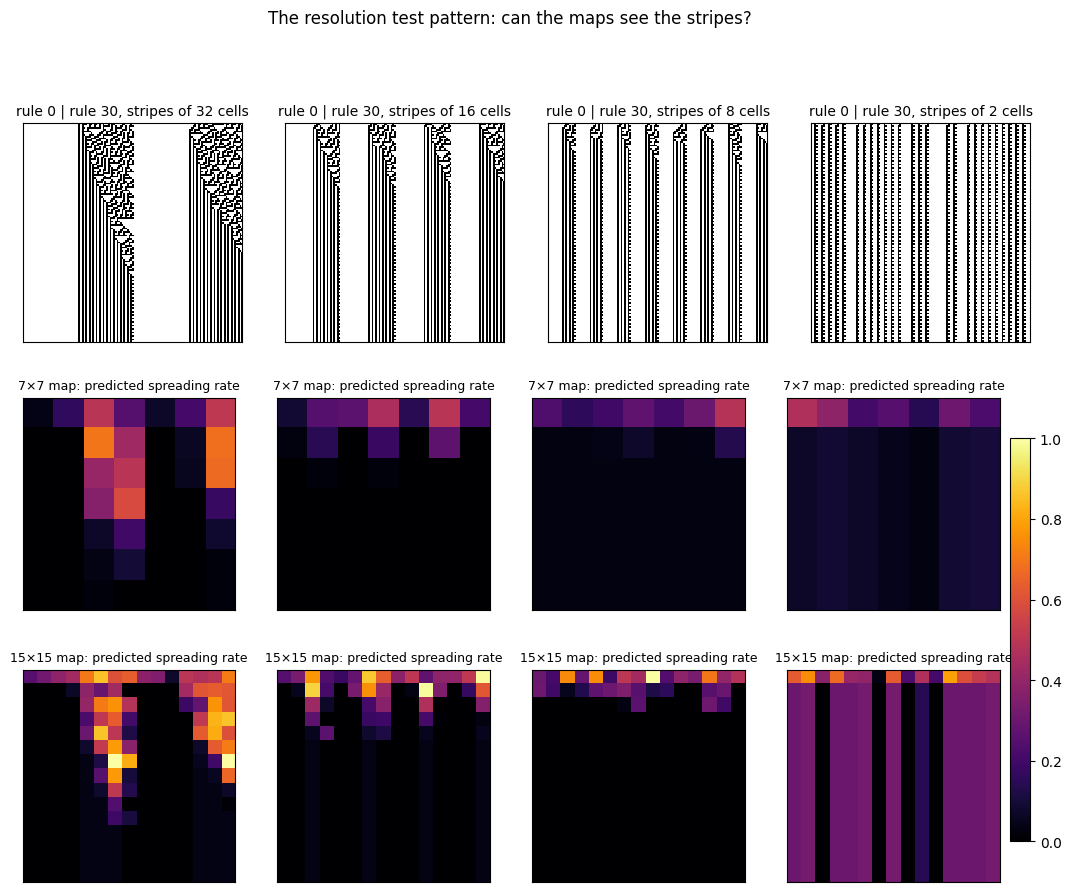

Criterion 8a — median relative contrast R(p) over 78 pairs
 stripe width |  7×7 map | 15×15 map
------------------------------------
        32 px |    0.761 |     0.873
        16 px |    0.302 |     0.648
         8 px |    0.003 |     0.230
         4 px |   -0.002 |     0.001
         2 px |    0.001 |    -0.003
------------------------------------
   7×7: gate at 32 px -> PASS (mean R 0.7243, CI95 [0.6925, 0.7541]); resolution limit (R ≥ 0.5): 32 px
 15×15: gate at 32 px -> PASS (mean R 0.8131, CI95 [0.7723, 0.8505]); resolution limit (R ≥ 0.5): 16 px


In [12]:
from caspectra.ca.nuca import striped_mask

# The 15x15 shallow network (runs/lever_a_shallow) joins the line-up.
cfg_sh = ExperimentConfig.from_yaml(str(ROOT / "configs/lever_a_shallow.yaml"))
ck_sh = torch.load(ROOT / "runs/lever_a_shallow/checkpoint_final.pt",
                   map_location="cpu", weights_only=False)
model_shallow = build_model(cfg_sh.model)
model_shallow.load_state_dict(ck_sh["model_state"])
model_shallow.eval()
mean_s = torch.tensor(ck_sh["scaler_mean"], dtype=torch.float32)
std_s = torch.tensor(ck_sh["scaler_std"], dtype=torch.float32)


def striped(rule_a, rule_b, period, phase=0, seed=11):
    mask = np.roll(striped_mask(127, period), phase)
    rng = np.random.default_rng(seed)
    return NonUniformCA(rule_a, rule_b, mask).random_diagram(127, 127, rng)


periods_shown = [32, 16, 8, 2]
fig, axes = plt.subplots(3, len(periods_shown), figsize=(13, 10))
for col, p in enumerate(periods_shown):
    img = striped(0, 30, p)
    axes[0, col].imshow(img, cmap="binary", interpolation="nearest")
    axes[0, col].set_title(f"rule 0 | rule 30, stripes of {p} cells", fontsize=10)
    for row, (model_, mean_, std_, label) in enumerate(
        [(model_local, mean_l, std_l, "7×7 map"),
         (model_shallow, mean_s, std_s, "15×15 map")], start=1):
        pmap = phenotype_map(model_, mean_, std_, img)
        im = axes[row, col].imshow(pmap[RATE], cmap="inferno", vmin=0, vmax=1,
                                   interpolation="nearest")
        axes[row, col].set_title(f"{label}: predicted spreading rate", fontsize=9)
    for ax in axes[:, col]:
        ax.set_xticks([]); ax.set_yticks([])
fig.colorbar(im, ax=axes[1:, :].ravel().tolist(), fraction=0.02, pad=0.01)
fig.suptitle("The resolution test pattern: can the maps see the stripes?", y=0.99)
plt.show()

# The registered measurement (scripts/validate_stripes.py): 78 rule pairs,
# 16 random-phase starts each, contrast normalized per pair by its half/half.
def stripe_summary(run):
    with open(ROOT / run / "stripe_eval" / "summary.json") as fh:
        return json.load(fh)

s_local, s_shallow = stripe_summary("runs/lever_a_local"), stripe_summary("runs/lever_a_shallow")

print("Criterion 8a — median relative contrast R(p) over 78 pairs")
print(f"{'stripe width':>13} | {'7×7 map':>8} | {'15×15 map':>9}")
print("-" * 36)
for p in [32, 16, 8, 4, 2]:
    rl = s_local["criterion8a"]["relative_contrast_median"][str(p)]
    rs = s_shallow["criterion8a"]["relative_contrast_median"][str(p)]
    print(f"{p:>10} px | {rl:>8.3f} | {rs:>9.3f}")
print("-" * 36)
for name, s in [("7×7", s_local), ("15×15", s_shallow)]:
    a = s["criterion8a"]
    g = a["gate_period32"]
    print(f"{name:>6}: gate at 32 px -> {g['verdict']} (mean R {g['mean_relative_contrast']}, "
          f"CI95 {g['ci95']}); resolution limit (R ≥ 0.5): {a['resolution_limit_px']} px")

Read the table like an optics bench. Both networks clear the pre-registered
minimum (positive contrast at 32-cell stripes, confidence interval well away
from zero). The 7×7 map sees 32-cell stripes clearly but is mostly blind by
16 — its resolution limit, under the registered "half the contrast survives"
definition, is **32 cells**. The 15×15 map holds most of its contrast at 16
cells and still shows a real residual at 8: resolution limit **16 cells** —
one octave finer, exactly what its doubled map resolution promises. Below
4-cell stripes: nothing, for either network, as receptive-field geometry
demands.

So §8's recommendation survives its own audit: the shallow network genuinely
*sees twice as fine*. Which sets up a better question than "can it see the
stripes?" — namely, what **should** a map read where it cannot resolve the
pattern at all?

### Below the resolution limit: alloys, not averages

The tempting answer — "just average the two rules' numbers" — is measurably
wrong. A composed system at stripe width 2 is not a blend of its parents; it
is a **new homogeneous universe**, an *alloy* in the metallurgical sense, and
its behaviour can be emergent. The showcase: dilute the chaotic rule 30 with
stripes of the dead rule 0. The dead stripes sever all communication between
the live cells, so a perturbation can never travel — damage freezes in place.
The alloy's *true* spreading rate collapses to almost zero, where the
average-the-parents answer predicts a briskly spreading ≈ 0.3.

And because the alloy is a bona-fide dynamical system, its invariants can be
measured directly — the same twin-run experiment, run on the composed
simulator. That makes the harshest exam yet possible (**criterion 8b**,
bars registered with the rest): the frozen network, trained on 70 uniform
ECAs, must read the invariants of **240 systems that are not ECAs at all**
(120 rule pairs × stripe widths 2 and 4), and to mean anything it must beat
the pre-registered mixture baseline.

In [13]:
from caspectra.data.targets import (
    load_or_compute_alloy_targets,
    load_or_compute_invariant_targets,
)
from itertools import combinations

PANEL = [0, 4, 204, 184, 26, 73, 154, 90, 60, 30, 18, 45, 22, 41, 106, 54]
panel_pairs = list(combinations(PANEL, 2))
pure = load_or_compute_invariant_targets(PANEL, width=127, n_pairs=256, seed=0,
                                         cache_dir=str(ROOT / "cache"))
pure_by_rule = {r: pure[i] for i, r in enumerate(PANEL)}
alloy2 = load_or_compute_alloy_targets(panel_pairs, 2, width=127, n_pairs=256,
                                       seed=0, cache_dir=str(ROOT / "cache"))
alloy_by_pair = {p: alloy2[i] for i, p in enumerate(panel_pairs)}


def global_reading(model_, mean_, std_, img):
    return phenotype_map(model_, mean_, std_, img).mean(axis=(1, 2))


print("Width-2 alloys: true spreading rate vs the 'average the parents' guess,")
print("and what each frozen network actually reads (mean over 8 random starts)\n")
print(f"{'alloy':>12} | {'true rate':>9} | {'mixture':>7} | {'7×7 reads':>9} | {'15×15 reads':>11}")
print("-" * 62)
for pair in [(0, 30), (0, 90), (204, 30), (30, 54)]:
    true_rate = alloy_by_pair[pair][RATE]
    mix_rate = 0.5 * (pure_by_rule[pair[0]][RATE] + pure_by_rule[pair[1]][RATE])
    reads = {}
    for key, (model_, mean_, std_) in {"7×7": (model_local, mean_l, std_l),
                                       "15×15": (model_shallow, mean_s, std_s)}.items():
        vals = []
        for i in range(8):
            img = striped(*pair, period=2, phase=i * 17, seed=100 + i)
            vals.append(global_reading(model_, mean_, std_, img)[RATE])
        reads[key] = float(np.mean(vals))
    print(f"{str(pair):>12} | {true_rate:>9.3f} | {mix_rate:>7.3f} "
          f"| {reads['7×7']:>9.3f} | {reads['15×15']:>11.3f}")

print("\nCriterion 8b — R² against the alloys' own twin-run invariants")
print("(240 alloys × 8 starts; registered bars: pass ≥ 0.5, fail < 0.2 on the median)\n")
print(f"{'invariant':>16} | {'7×7 map':>8} | {'15×15 map':>9} | {'mixture':>8}")
print("-" * 52)
b_l, b_s = s_local["criterion8b"], s_shallow["criterion8b"]
for name in DYNAMICS_FEATURE_NAMES:
    print(f"{name:>16} | {b_l['per_feature_r2_map'][name]:>8.3f} "
          f"| {b_s['per_feature_r2_map'][name]:>9.3f} "
          f"| {b_l['per_feature_r2_mixture'][name]:>8.3f}")
print("-" * 52)
print(f"{'gated median':>16} | {b_l['median_r2_map_gated']:>8.3f} "
      f"| {b_s['median_r2_map_gated']:>9.3f} | {b_l['median_r2_mixture_gated']:>8.3f}")
print(f"{'verdict':>16} | {s_local['criterion8b_verdict']:>8} "
      f"| {s_shallow['criterion8b_verdict']:>9} | not gated")

Width-2 alloys: true spreading rate vs the 'average the parents' guess,
and what each frozen network actually reads (mean over 8 random starts)

       alloy | true rate | mixture | 7×7 reads | 15×15 reads
--------------------------------------------------------------
     (0, 30) |     0.009 |   0.311 |     0.046 |       0.144
     (0, 90) |     0.008 |   0.496 |     0.035 |       0.091
   (204, 30) |     0.016 |   0.315 |     0.041 |       0.081
    (30, 54) |     0.477 |   0.519 |     0.626 |       0.749

Criterion 8b — R² against the alloys' own twin-run invariants
(240 alloys × 8 starts; registered bars: pass ≥ 0.5, fail < 0.2 on the median)

       invariant |  7×7 map | 15×15 map |  mixture
----------------------------------------------------
 damage_survival |    0.623 |     0.328 |    0.320
 damage_fraction |    0.610 |     0.704 |    0.339
  spreading_rate |    0.478 |     0.408 |    0.233
       cone_fill |    0.258 |     0.064 |   -0.538
------------------------------------

Three things worth saying carefully.

**The quench showcase is real, and the networks see it.** The width-2
rule-0/rule-30 alloy truly freezes (rate ≈ 0.01); the mixture guess insists on
≈ 0.31; the 7×7 network reads ≈ 0.04 and the 15×15 ≈ 0.14. Neither network was
ever shown a non-uniform system during training — they are reading the actual
local dynamics in the picture, not recalling their parents' textures. (The
hot-times-hot alloy of 30 and 54 is read hot by both, though somewhat over.)

**The deep map passes; the shallow map does not.** Across all 240 alloys the
7×7 network's gated median is **0.544 — a pass**, clearing the registered bar
with little headroom, and it beats the mixture baseline on **every** invariant
(the mixture is outright anti-correlated on cone fill). The 15×15 network
lands at 0.368 — **inconclusive** under the registered bars: still better
than the mixture overall, not good enough to certify. Its weakness sits in
damage survival and cone fill, the same calibration soft spot §8 documented.

**The trade now has both sides measured.** Depth buys robustness on emergent,
out-of-distribution dynamics; shallowness buys spatial resolution. "Pick the
checkpoint by use case" survives, with sharper content than we could honestly
claim before this section: 7×7 to *trust the reading* on novel or mixed
physics, 15×15 to *localize where* the physics changes. Stated plainly for
the record: cone fill is weakly read on alloys by both networks, and 0.544
is a pass without swagger.

## 10. A bigger universe: giving complexity room to exist

Section 6 left one stubborn flaw. The amortizer reads the four behaviour numbers
off a never-seen rule beautifully — *unless* that rule is **complex** (a
glider-supporting, edge-of-chaos rule like 110 or 54). Then it misses, always in
the same telling way: it rounds the complex rule toward whichever ordinary
regime it has seen many examples of. The diagnosis was never "the method is
broken" but "the *training set* is too poor": among the 88 elementary rules
there are only **two** complex ones. You cannot learn a category from two
examples.

There is one real cure — a universe with more room for complexity. Widen the
neighbourhood: let every cell look *two* neighbours out on each side instead of
one (a **range-2** rule). The spirit is unchanged — still binary cells, still
the same damage-spreading behaviour numbers, still the reflection/complement
symmetries — but the rule space explodes from 256 to about **four billion**, and
complex rules should become plentiful instead of a two-member club. That is the
M4 experiment, its bars pre-registered (**criterion 9**, revision 5) before a
single range-2 rule was drawn.

First question, and the one everything hinges on: in this bigger universe, *how
common is complexity?*

Complex rules in the range-2 sample: 57/800 = 7.1%
(For comparison, elementary CAs: ~2 complex rules in 88 = ~2%.)

Famous ECAs embedded into range-2, and where they land:
             0 dead: rate 0.00, fill 0.00  ->  complex=False
          204 fixed: rate 0.01, fill 1.00  ->  complex=False
        184 traffic: rate 0.05, fill 1.00  ->  complex=False
         30 chaotic: rate 0.31, fill 0.53  ->  complex=False
        90 additive: rate 0.49, fill 0.27  ->  complex=False
         54 complex: rate 0.23, fill 0.50  ->  complex=True
        110 complex: rate 0.22, fill 0.57  ->  complex=True


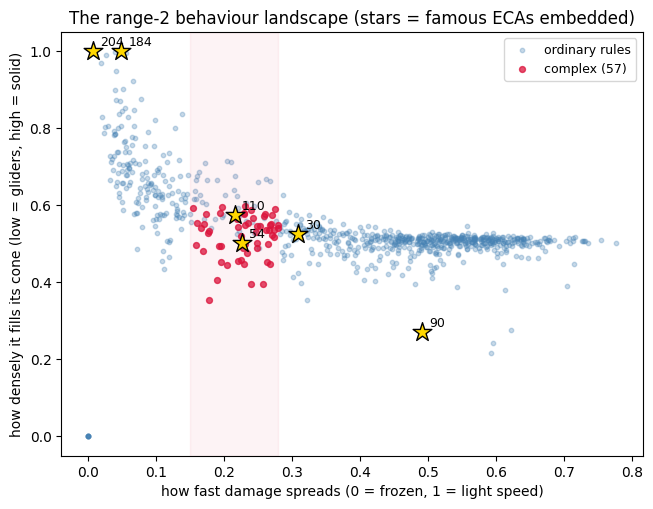

In [14]:
from caspectra.ca.range_ca import RangeCA, sample_rules
from caspectra.data.targets import load_or_compute_invariant_targets
from caspectra.eval.regimes import COMPLEX_SIGNATURE, complex_mask, curated_anchors, is_complex

# The same 800 canonical range-2 rules the experiment used (deterministic seed),
# with their behaviour numbers measured under the range-2 protocol (cached).
rules_r2 = sample_rules(800, 2, np.random.default_rng(0))
targets_r2 = load_or_compute_invariant_targets(
    rules_r2, width=127, n_pairs=256, seed=0, cache_dir=str(ROOT / "cache"), radius=2)
order = {r: i for i, r in enumerate(sorted(rules_r2))}
targets_r2 = targets_r2[[order[r] for r in rules_r2]]
mask_r2 = complex_mask(targets_r2)

RATE_I = DYNAMICS_FEATURE_NAMES.index("spreading_rate")
FILL_I = DYNAMICS_FEATURE_NAMES.index("cone_fill")

# Where do the *famous* complex ECAs sit once embedded into the range-2 space?
anchors = {name: damage_spreading_features(simulator=RangeCA(rule, 2), width=127,
                                           n_pairs=256, rng=np.random.default_rng(rule % (2**31)))
           for name, rule in curated_anchors(2).items()}

frac = mask_r2.mean()
print(f"Complex rules in the range-2 sample: {mask_r2.sum()}/{len(rules_r2)} = {frac:.1%}")
print(f"(For comparison, elementary CAs: ~2 complex rules in 88 = ~2%.)\n")
print("Famous ECAs embedded into range-2, and where they land:")
for name, v in anchors.items():
    tag = name.replace('eca', '').replace('_', ' ')
    print(f"   {tag:>16}: rate {v[RATE_I]:.2f}, fill {v[FILL_I]:.2f}  ->  complex={is_complex(v)}")

fig, ax = plt.subplots(figsize=(7.5, 5.5))
ax.scatter(targets_r2[~mask_r2, RATE_I], targets_r2[~mask_r2, FILL_I], s=10, alpha=0.3,
           c="steelblue", label="ordinary rules")
ax.scatter(targets_r2[mask_r2, RATE_I], targets_r2[mask_r2, FILL_I], s=18, alpha=0.75,
           c="crimson", label=f"complex ({mask_r2.sum()})")
for name, v in anchors.items():
    if name.startswith("eca") and v[RATE_I] > 0:
        ax.scatter([v[RATE_I]], [v[FILL_I]], marker="*", s=200, c="gold", edgecolor="k", zorder=5)
        ax.annotate(name.replace("eca", "").split("_")[0], (v[RATE_I], v[FILL_I]),
                    textcoords="offset points", xytext=(5, 4), fontsize=9)
ax.axvspan(COMPLEX_SIGNATURE["rate_lo"], COMPLEX_SIGNATURE["rate_hi"], color="crimson", alpha=0.05)
ax.set_xlabel("how fast damage spreads (0 = frozen, 1 = light speed)")
ax.set_ylabel("how densely it fills its cone (low = gliders, high = solid)")
ax.set_title("The range-2 behaviour landscape (stars = famous ECAs embedded)")
ax.legend(fontsize=9)
plt.show()

The picture is the edge of chaos, drawn from data. The four-billion-rule universe
sorts itself into three territories: an **ordered** arm climbing to the top-left
(damage barely moves, fills a solid cone — the embedded *204*/*184* live here), a
dense **chaotic** bulk on the right (damage races outward near light speed), and
in between, a distinct **complex band** (the red stripe) — damage that persists
and travels but stays sparse and localized, the signature of gliders. The famous
complex ECAs *54* and *110*, embedded into this larger space, land squarely in
that red band; the ordered, chaotic and additive anchors land exactly where they
should and are *not* flagged. (A reassurance the code checks silently: an
embedded ECA reproduces its elementary diagrams bit-for-bit, so these stars are
genuinely the rules we know.)

And the headline number: **complexity is now common** — around one rule in
fourteen, versus one in forty-four among the ECAs, and dozens of rules in
absolute terms instead of two. For the first time we can hold out a whole
*population* of complex rules and ask the honest question §6 could never afford
to: shown many complex universes but *never these ones*, does the network place
them correctly — or does it still round them toward the nearest crowd?

In [15]:
import json

with open(ROOT / "runs/m4_range2/complex_eval/summary.json") as fh:
    m4 = json.load(fh)

print("Criterion 9 — placing 57 held-out COMPLEX range-2 rules (never trained on)\n")
print(f"{'invariant':>16} | {'R² (complex hold-out)':>21}")
print("-" * 42)
for name in DYNAMICS_FEATURE_NAMES:
    print(f"{name:>16} | {m4['complex_per_feature_r2'][name]:>21.3f}")
print("-" * 42)
print(f"{'median':>16} | {m4['complex_median_r2']:>21.3f}   (pre-registered bar ≥ 0.5)\n")

print("The bias test — does it still round complex rules toward a neighbour?")
print(f"   range-2, 57 complex held out : mean spreading-rate error = "
      f"{m4['complex_signed_rate_error']:+.3f}   (bar |·| ≤ 0.10)")
base = m4['eca_section6_baseline_signed_rate_error']
print(f"   ECA §6 baseline, rule 110    : {base['rule110_held']:+.2f}   (read hot: 0.54 vs true 0.37)")
print(f"   ECA §6 baseline, rule  54    : {base['rule54_held']:+.2f}   (read cold: 0.18 vs true 0.44)")
print(f"\n   general (non-complex) hold-out median R² = {m4['general_median_r2']:.3f}")
print(f"   CRITERION 9: {m4['criterion9_verdict']}")

Criterion 9 — placing 57 held-out COMPLEX range-2 rules (never trained on)

       invariant | R² (complex hold-out)
------------------------------------------
 damage_survival |                 0.739
 damage_fraction |                 0.914
  spreading_rate |                 0.906
       cone_fill |                 0.410
------------------------------------------
          median |                 0.822   (pre-registered bar ≥ 0.5)

The bias test — does it still round complex rules toward a neighbour?
   range-2, 57 complex held out : mean spreading-rate error = +0.012   (bar |·| ≤ 0.10)
   ECA §6 baseline, rule 110    : +0.17   (read hot: 0.54 vs true 0.37)
   ECA §6 baseline, rule  54    : -0.26   (read cold: 0.18 vs true 0.44)

   general (non-complex) hold-out median R² = 0.849
   CRITERION 9: PASS


That is the section-6 caveat **repaired, not excused**. Given a populated
complex regime, the amortizer places 57 never-seen complex rules with a median
R² of about **0.82** and — the decisive number — an average spreading-rate error
of **+0.01**, essentially zero. The old pull is gone: on the elementary rules a
held-out complex rule was dragged by *+0.17* (read as hot chaos) or *−0.26*
(read as tame order); here the same kind of rule lands on the diagonal. The
mis-placement was never a limit of the idea — it was two data points pretending
to be a category. (One honest wrinkle survives: *cone fill*, the glider-vs-chaos
texture, is still the hardest number to read, R² ≈ 0.41 — the median clears the
bar comfortably without it.)

The deeper point is the one this whole notebook has been building toward. A
network that had merely memorized a lookup table of the rules it trained on
could not do this — there is no lookup entry for a range-2 rule it has never
seen. To place it correctly it must be reading the *behaviour* in the picture.
Populate the space with genuine complexity, and the estimator finds it.

## 11. Scoreboard and what's next

Everything measured so far, in one table (details and dates in `RESULTS.md`):

| Question | Verdict |
|---|---|
| Can texture-SSL discover the behaviour classes label-free? | **No** — it identifies rules, not behaviour (gap ≈ 0; complex-class recall 0.00). Kept as the frozen negative baseline. |
| Is a "true", assumption-free classification even well-posed? | **No** (literature): undecidable in general, protocol-dependent, no bias-free clustering. Claims are now protocol-explicit. |
| Do four twin-run invariants sort behaviour well? | **Yes** — complex-class recall 1.00, interpretable regimes, {54, 110} robustly grouped under the stated protocol. |
| Are those invariants predictable from a *single* image of a never-seen rule? | **Yes** — pre-registered criterion 6 **passed twice** (median R² 0.863 / 0.836 vs bar 0.5). |
| Does one complex training example suffice to place an unseen complex rule? | **No** — mirror-image misses for 110/54; complexity needs a populated regime. |
| Can behaviour be mapped *spatially* from one image? | **Qualitatively yes** — coarse (7×7) but physically sensible phenotype maps. |
| Do the maps stay honest when the physics *varies in space*? | **Yes, after one fix** — pre-registered criterion 7: the original network was inconclusive (0.433; whole-image normalization leaked context between regions), a one-variable local-norm retrain **passes (0.831, and 0.863 on never-seen rules)** with criterion 6 intact. |
| How finely can the maps localize behaviour in space? | **Measured** — pre-registered criterion 8a: resolution limit 32 cells (7×7 map) vs 16 cells (15×15 map), one octave finer exactly as the doubled map resolution promises; both pass the gate; both blind below 4-cell stripes, as geometry demands. |
| Below its resolution, does the network read emergent physics or average textures? | **Emergent — for the deep map**: criterion 8b grades the readings against 240 rule-*alloys* (not ECAs at all, e.g. rule 30 quenched to stillness by dead stripes). 7×7 **passes (0.544)** and beats the mixture baseline on every invariant; 15×15 is **inconclusive (0.368)**, above the mixture but below the bar. |
| Was the complex-placement failure (§6) a limit of the method or just too little data? | **Just data** — pre-registered criterion 9 (M4): a *range-2* rule space makes complex rules common (≈ 7 %, vs ~2 % in ECAs); trained leave-complex-out, the amortizer places **57 never-seen complex rules** with median R² **0.82** and near-zero spreading-rate bias (**+0.01** vs the ECA pull of +0.17 / −0.26). The two-member-club caveat is repaired. |

**Open directions**, roughly in order of leverage:

1. **A larger rule space** — *done* (§10): range-2 CAs make complex rules
   plentiful and **repair the §6 caveat** (criterion 9 pass, held-out complex
   placement unbiased). Natural continuations: richer complex sub-types, and
   range-2 non-uniform maps (criteria 7–8 in the larger space).
2. **Richer invariants** — extend the target family (e.g. Lyapunov-spectrum
   estimates) so "behaviour" is a fuller experimental profile.
3. **Sharper phenotype maps** — now measured from both sides (§9): the shallow
   encoder resolves one octave finer (16 vs 32 cells) but reads emergent alloy
   dynamics worse (criterion 8b: inconclusive 0.368 vs the deep network's pass
   at 0.544). Depth buys out-of-distribution robustness, shallowness buys
   resolution; a multi-scale head is the obvious synthesis candidate.
4. **Predictive self-supervision** — the one remaining "discovery-flavoured"
   lever (predict the *future* of a diagram rather than compare augmented
   views); strictly optional now, with pre-registered kill criteria.

The one-line summary of the pivot: **we stopped asking the network to invent
the science, and started asking it to speed up the experiment.** That question,
it turns out, it can answer.